In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn import preprocessing

In [2]:
df = read_csv("../../datasets/iris.csv")
df.head(9)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa


In [3]:
iris_codes = {'Iris-setosa': 1, 'Iris-versicolor': 2, 'Iris-virginica': 3}

df['Species_codes'] = df['Species'].map(iris_codes).astype(int)

# You can use df.isnull().values.any() to to check if df has any missing data

df.head(9)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species,Species_codes
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1
5,5.4,3.9,1.7,0.4,Iris-setosa,1
6,4.6,3.4,1.4,0.3,Iris-setosa,1
7,5.0,3.4,1.5,0.2,Iris-setosa,1
8,4.4,2.9,1.4,0.2,Iris-setosa,1


In [4]:
print(df['Species_codes'].value_counts())
print(df.columns)

Species_codes
1    50
2    50
3    50
Name: count, dtype: int64
Index(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species',
       'Species_codes'],
      dtype='object')


In [5]:
# put .values in the end to lose headers
X = df[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']].values
X[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [6]:
Y = df['Species_codes'].values
Y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [7]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X)

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=5)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)


training data:  (120, 4) (120,)
testing data:  (30, 4) (30,)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
Ks = 16
mean_acc = np.zeros((Ks-1))
fscores = np.zeros((Ks-1))

for n in range(1, Ks):
    neigh = KNeighborsClassifier(n_neighbors=n).fit(x_train, y_train)
    yhat = neigh.predict(x_test)

    print(f"k={n} acc={accuracy_score(y_test, yhat)} f1_s={f1_score(y_test, yhat, average=None)}")


k=1 acc=0.8666666666666667 f1_s=[1.         0.81818182 0.81818182]
k=2 acc=0.9 f1_s=[1.         0.86956522 0.85714286]
k=3 acc=0.9 f1_s=[1.         0.86956522 0.85714286]
k=4 acc=0.9 f1_s=[1.         0.86956522 0.85714286]
k=5 acc=0.9333333333333333 f1_s=[1.         0.90909091 0.90909091]
k=6 acc=0.9666666666666667 f1_s=[1.         0.95652174 0.95238095]
k=7 acc=0.9666666666666667 f1_s=[1.         0.95652174 0.95238095]
k=8 acc=0.9666666666666667 f1_s=[1.         0.95652174 0.95238095]
k=9 acc=0.9333333333333333 f1_s=[1.         0.90909091 0.90909091]
k=10 acc=0.9666666666666667 f1_s=[1.         0.95652174 0.95238095]
k=11 acc=0.9666666666666667 f1_s=[1.         0.95652174 0.95238095]
k=12 acc=0.9666666666666667 f1_s=[1.         0.95652174 0.95238095]
k=13 acc=0.9333333333333333 f1_s=[1.         0.90909091 0.90909091]
k=14 acc=0.9333333333333333 f1_s=[1.         0.90909091 0.90909091]
k=15 acc=0.9 f1_s=[1.         0.85714286 0.86956522]


In [10]:
# K can be 6
neigh = KNeighborsClassifier(n_neighbors=6).fit(x_train, y_train)
neigh

KNeighborsClassifier(n_neighbors=6)

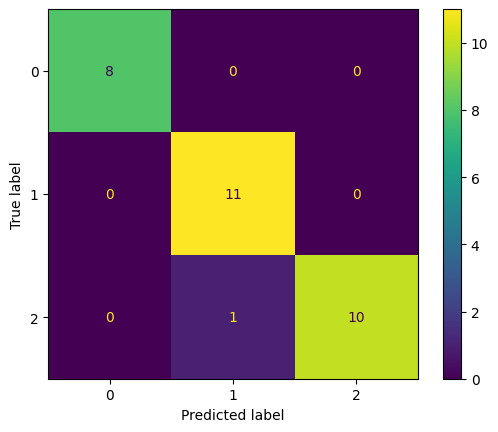

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
yhat = neigh.predict(x_test)
cm = confusion_matrix(y_test, yhat)
disp = ConfusionMatrixDisplay(cm)
disp.plot()